# Results from the ML model with `GenMET_pt` as target

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import shap
import sys

sys.path.append("../../MET_models/")
from MET_pt_testing import load_model_and_scaler

/home/matilde/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/matilde/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E0000 00:00:1784177748.611481  737748 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plu

In [2]:
def load_predictions(event: str):
    """
        Loads MET_pt_pred, MET_pt (reco) and GenMET_pt from the parquet
        saved by the prediction on dataset.
    """
    parquet_path = os.path.join(f"predictions_testing_{event}.parquet")

    if not os.path.exists(parquet_path):
        raise FileNotFoundError(f"Parquet not found: {parquet_path}")

    df = pd.read_parquet(parquet_path)

    if "MET_pt_pred" not in df.columns:
        raise ValueError(f"Column 'MET_pt_pred' missing in {parquet_path}")

    Y_pred = df["MET_pt_pred"].to_numpy()
    y_true = df["GenMET_pt"].to_numpy() if "GenMET_pt" in df.columns else None
    MET_pt = df["MET_pt"].to_numpy() if "MET_pt" in df.columns else None

    if y_true is None:
        print(f"  [WARNING] 'GenMET_pt' not found in {parquet_path}")
    if MET_pt is None:
        print(f"  [WARNING] 'MET_pt' not found in {parquet_path}")

    print(f"  Loaded {len(df):,} events from '{parquet_path}'")
    print(f"  Columns found: {list(df.columns)}")

    return Y_pred, y_true, MET_pt

In [ ]:
def _compute_metrics(Y_pred, y_true, MET_pt, label):
    """
        Prints MSE/RMSE/MAE/R² for pt,
        both for reco vs Gen and predicted vs Gen,
        plus absolute and relative improvements.
    """
    rmse_reco = np.sqrt(mean_squared_error(y_true, MET_pt))
    mae_reco  = mean_absolute_error(y_true, MET_pt)
    r2_reco   = r2_score(y_true, MET_pt)
    std_reco  = np.std(MET_pt - y_true)

    print(f"Reconstruction performance for {label}:")
    print(f"    RMSE = {rmse_reco:.4f} GeV")
    print(f"    MAE  = {mae_reco:.4f} GeV")
    print(f"    R²   = {r2_reco:.4f}")
    print(f"    Std(residuals) = {std_reco:.4f} GeV")

    rmse_pred = np.sqrt(mean_squared_error(y_true, Y_pred))
    mae_pred  = mean_absolute_error(y_true, Y_pred)
    r2_pred   = r2_score(y_true, Y_pred)
    std_pred  = np.std(Y_pred - y_true)

    print(f"ML model performance for {label}:")
    print(f"    RMSE = {rmse_pred:.4f} GeV")
    print(f"    MAE  = {mae_pred:.4f} GeV")
    print(f"    R²   = {r2_pred:.4f}")
    print(f"    Std(residuals) = {std_pred:.4f} GeV")

    DELTA_rmse = rmse_reco - rmse_pred
    DELTA_mae  = mae_reco - mae_pred
    DELTA_r2   = r2_pred - r2_reco
    DELTA_std  = std_reco - std_pred

    pct_rmse = DELTA_rmse / rmse_reco * 100
    pct_mae  = DELTA_mae / mae_reco  * 100
    pct_r2   = DELTA_r2 / abs(r2_reco) * 100 if r2_reco != 0 else float("nan")
    pct_std  = DELTA_std / std_reco * 100

    print(f"Performance improvement for {label}:")
    print(f"    DELTA_RMSE = {DELTA_rmse:.4f} GeV   {pct_rmse:+.2f}%")
    print(f"    DELTA_MAE  = {DELTA_mae:.4f} GeV    {pct_mae:+.2f}%")
    print(f"    DELTA_R²   = {DELTA_r2:.4f}    {pct_r2:+.2f}%")
    print(f"    DELTA_STD  = {DELTA_std:.4f}    {pct_std:+.2f}%")
    return

In [4]:
def _plot_fold_learning_curves(df_folds):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"CV Fold Learning Curves", fontsize=13, fontweight="bold")
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for fh in df_folds.groupby("fold"):
        fold_idx, df = fh
        c = colors[(fold_idx - 1) % len(colors)]
        axes[0].plot(df["epoch"], df["loss"],     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[0].plot(df["epoch"], df["val_loss"], color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")
        axes[1].plot(df["epoch"], df["loss"].pow(0.5),     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[1].plot(df["epoch"], df["val_loss"].pow(0.5), color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")

    for ax, ylabel, title in zip(axes, ["[GeV$^2$]", "[GeV]"], ["MSE Loss", "RMSE"]):
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

In [5]:
def _plot_learning_curves(df_lc):
    epochs  = range(1, len(df_lc) + 1)
    has_val = "val_loss" in df_lc.columns
    has_mse = "mse" in df_lc.columns

    fig, axes = plt.subplots(1, 2 if has_mse else 1, figsize=(14 if has_mse else 7, 5))
    if not has_mse:
        axes = [axes]
    fig.suptitle(f"Retraining Learning Curves", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(epochs, df_lc["loss"], color="red", lw=1.5, label="Train loss")
    if has_val:
        axes[0].plot(epochs, df_lc["val_loss"], color="blue", lw=1.5, label="Val loss")
    axes[0].set_title("MSE Loss", fontsize=11)
    axes[0].set_xlabel("Epoch", fontsize=10)
    axes[0].set_ylabel("[GeV$^2$]", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # RMSE
    if has_mse:
        axes[1].plot(epochs, df_lc["mse"].pow(0.5), color="red", lw=1.5, label="Train RMSE")
        if has_val:
            axes[1].plot(epochs, df_lc["val_mse"].pow(0.5), color="blue", lw=1.5, label="Val RMSE")
        axes[1].set_title("RMSE", fontsize=11)
        axes[1].set_xlabel("Epoch", fontsize=10)
        axes[1].set_ylabel("[GeV]", fontsize=10)
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Retraining learning curves:")
    print(f"    Epochs run       : {len(df_lc)}")
    print(f"    Final train loss : {df_lc['loss'].iloc[-1]:.4f}")
    if has_val:
        print(f"    Final val loss   : {df_lc['val_loss'].iloc[-1]:.4f}")
        print(f"    Best val loss    : {df_lc['val_loss'].min():.4f}  "
              f"(epoch {df_lc['val_loss'].idxmin() + 1})")
    return

In [6]:
def _scatterplot_reco_vs_gen(MET_pt: np.ndarray, y_true: np.ndarray, event: str, color: str):
    """
        Scatter plot of reconstructed MET_pt vs GenMET_pt.
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(y_true, MET_pt, alpha=0.3, s=8, color=color, rasterized=True)

    # identity line y = x
    lims = [
        min(y_true.min(), MET_pt.min()),
        max(y_true.max(), MET_pt.max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x")

    r2 = r2_score(y_true, MET_pt)
    rmse = np.sqrt(mean_squared_error(y_true, MET_pt))
    ax.text(0.05, 0.92, f"RMSE = {rmse:.2f} GeV\n$R^2$ = {r2:.4f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_xlabel("GenMET_pt [GeV]", fontsize=12)
    ax.set_ylabel("Reconstructed MET_pt [GeV]", fontsize=12)
    ax.set_title(f"Reconstructed MET_pt vs GenMET_pt - {event}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return

In [7]:
def _scatterplot_pred_vs_gen(y_pred: np.ndarray, y_true: np.ndarray, event: str, color: str):
    """
        Scatter plot of Predicted MET_pt vs GenMET_pt.
    """
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(y_true, y_pred, alpha=0.3, s=8, color=color, rasterized=True)

    # identity line y = x
    lims = [
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x")

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.92, f"RMSE = {rmse:.2f} GeV\n$R^2$ = {r2:.4f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_xlabel("GenMET_pt [GeV]", fontsize=12)
    ax.set_ylabel("Predicted MET_pt [GeV]", fontsize=12)
    ax.set_title(f"Predicted MET_pt vs GenMET_pt - {event}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return

In [8]:
def _response_and_residual_plots(y_pred: np.ndarray, y_true: np.ndarray,
                   MET_pt: np.ndarray, event: str):
    """
        Response and residual distribution plots for both predicted and reconstructed MET vs GenMET.
        - Left : histogram of response (MET/GenMET) for pred and reco overlaid;
        - Right: histogram of residuals (MET-GenMET) for pred and reco overlaid.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Response and Residuals - {event}", fontsize=14, fontweight="bold")

    # Left: response histogram
    mask       = y_true > 0
    resp_pred  = y_pred[mask] / y_true[mask]
    resp_reco  = MET_pt[mask] / y_true[mask]

    bins = np.linspace(0, 3, 80)
    mu_pred, sig_pred = resp_pred.mean(), resp_pred.std()
    mu_reco, sig_reco = resp_reco.mean(), resp_reco.std()
    axes[0].hist(resp_pred, bins=bins, alpha=0.6, color="darkorange",
                 label=f"Pred ($\mu$={mu_pred:.2e}, $\sigma$={sig_pred:.2e})")
    axes[0].hist(resp_reco, bins=bins, alpha=0.6, color="steelblue",
                 label=f"Reco ($\mu$={mu_reco:.2e}, $\sigma$={sig_reco:.2e})")
    axes[0].axvline(1, color="red", linestyle="--", linewidth=1.2, label="ideal = 1")
    axes[0].set_xlabel("MET/GenMET_pt", fontsize=12)
    axes[0].set_ylabel("Events", fontsize=12)
    axes[0].set_title("Response distribution", fontsize=12)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # Right: residual histogram
    res_pred = y_pred - y_true
    res_reco = MET_pt - y_true

    bins = np.linspace(
        min(res_pred.min(), res_reco.min()),
        max(res_pred.max(), res_reco.max()),
        80
    )
    axes[1].hist(res_pred, bins=bins, alpha=0.6, color="darkorange",
                 label=f"Pred  ($\mu$={res_pred.mean():.2f}, $\sigma$={res_pred.std():.2f})")
    axes[1].hist(res_reco, bins=bins, alpha=0.6, color="steelblue",
                 label=f"Reco  ($\mu$={res_reco.mean():.2f}, $\sigma$={res_reco.std():.2f})")
    axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2, label="ideal = 0")
    axes[1].set_xlabel("MET - GenMET [GeV]", fontsize=12)
    axes[1].set_ylabel("Events", fontsize=12)
    axes[1].set_title("Residual distribution", fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

In [9]:
def _profile_histogram_residuals(y_pred: np.ndarray, y_true: np.ndarray,
                                  MET_pt: np.ndarray, event: str,
                                  bin_width: float = 10.0,
                                  min_counts: int = 10,
                                  min_Gen: float = 50.0):
    """
        Residuals profile histogram: (MET - GenMET) vs GenMET_pt.
        - left: profile histogram for mean of residuals;
        - right: profile histogram for standard deviation of residuals.
    """
    mask_pos   = y_true > min_Gen
    y_true_m   = y_true[mask_pos]
    res_pred   = y_pred[mask_pos] - y_true_m
    res_reco   = MET_pt[mask_pos] - y_true_m
    x_max  = np.ceil(y_true_m.max() / bin_width) * bin_width
    n_bins = int((x_max - min_Gen) / bin_width)
    bins   = np.linspace(min_Gen, x_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_indices = np.clip(np.digitize(y_true_m, bins) - 1, 0, n_bins - 1)
    counts_true    = np.array([(bin_indices == i).sum() for i in range(n_bins)])
    last_valid_bin = np.max(np.where(counts_true >= min_counts)[0])
    x_plot_max     = bins[last_valid_bin + 1]

    print(f"  Excluding GenMET_pt < {min_Gen} GeV: {(~mask_pos).sum():,} events removed.")
    print(f"  Plotting up to {x_plot_max:.0f} GeV.\n"
          f"  Last bin with >= {min_counts} events: [{bins[last_valid_bin]:.0f}, {bins[last_valid_bin+1]:.0f}] GeV, n={counts_true[last_valid_bin]}")
    
    arrays  = {"MET pred": res_pred, "MET reco": res_reco}
    colors  = {"MET pred": "darkorange", "MET reco": "steelblue"}
    markers = {"MET pred": "o",          "MET reco": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Residual Profile Histogram - {event}",
                 fontsize=14, fontweight="bold")
    
    for label, arr in arrays.items():
        means  = np.full(n_bins, np.nan)
        stds   = np.full(n_bins, np.nan)
        counts = np.zeros(n_bins, dtype=int)
        for i in range(n_bins):
            mask      = (bin_indices == i)
            counts[i] = mask.sum()
            if counts[i] >= min_counts:
                means[i] = arr[mask].mean()
                stds[i]  = arr[mask].std()
        valid = (counts >= min_counts) & (bin_centers <= x_plot_max)
        axes[0].errorbar(
            bin_centers[valid], means[valid], yerr=stds[valid],
            fmt="none", ecolor=colors[label], elinewidth=1.2,
            capsize=4, capthick=1.2,
        )
        axes[0].plot(
            bin_centers[valid], means[valid],
            marker=markers[label], color=colors[label], label=label,
            markersize=5, linewidth=1.2, linestyle="-"
        )
        axes[1].plot(
            bin_centers[valid], stds[valid],
            marker=markers[label], color=colors[label],
            label=label, markersize=5, linewidth=1.2
        )
    axes[0].axhline(0, color="red", linestyle="--", linewidth=1.2, label="ideal = 0")
    axes[0].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[0].set_ylabel("Mean (MET - GenMET_pt) [GeV]", fontsize=12)
    axes[0].set_title("Mean residual vs GenMET_pt", fontsize=12)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(min_Gen, x_plot_max)

    axes[1].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[1].set_ylabel("Std (MET - GenMET_pt) [GeV]", fontsize=12)
    axes[1].set_title("Residual resolution vs GenMET_pt", fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(min_Gen, x_plot_max)
    axes[1].set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()
    return

In [10]:
def _profile_histogram_response(y_pred: np.ndarray, y_true: np.ndarray,
                                 MET_pt: np.ndarray, event: str,
                                 bin_width: float = 10.0,
                                 min_counts: int = 10,
                                 min_Gen: float = 50.0):
    """
        Profile histogram of the response (MET / GenMET) vs GenMET_pt.
        - left: mean of the response per bin;
        - right: std of the response per bin (spread of MET/GenMET around the mean).
    """
    mask_pos = y_true > min_Gen
    y_true_m = y_true[mask_pos]
    pred_m   = y_pred[mask_pos]
    reco_m   = MET_pt[mask_pos]

    x_max  = np.ceil(y_true_m.max() / bin_width) * bin_width
    n_bins = int((x_max - min_Gen) / bin_width)
    bins   = np.linspace(min_Gen, x_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    bin_indices = np.clip(np.digitize(y_true_m, bins) - 1, 0, n_bins - 1)

    counts_true    = np.array([(bin_indices == i).sum() for i in range(n_bins)])
    last_valid_bin = np.max(np.where(counts_true >= min_counts)[0])
    x_plot_max     = bins[last_valid_bin + 1]

    print(f"  Excluding GenMET_pt < {min_Gen} GeV: {(~mask_pos).sum():,} events removed.")
    print(f"  Plotting up to {x_plot_max:.0f} GeV.\n"
          f"  Last bin with >= {min_counts} events: [{bins[last_valid_bin]:.0f}, {bins[last_valid_bin+1]:.0f}] GeV, n={counts_true[last_valid_bin]}")

    arrays  = {"MET pred": pred_m, "MET reco": reco_m}
    colors  = {"MET pred": "darkorange", "MET reco": "steelblue"}
    markers = {"MET pred": "o",          "MET reco": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Response Profile Histogram - {event}",
                 fontsize=14, fontweight="bold")

    for label, arr in arrays.items():
        response = np.where(y_true_m != 0, arr / y_true_m, np.nan)
        means  = np.full(n_bins, np.nan)
        stds   = np.full(n_bins, np.nan)
        counts = np.zeros(n_bins, dtype=int)

        for i in range(n_bins):
            mask_i    = (bin_indices == i)
            counts[i] = mask_i.sum()
            if counts[i] >= min_counts:
                means[i] = np.nanmean(response[mask_i])
                stds[i]  = np.nanstd(response[mask_i])

        valid = (counts >= min_counts) & (bin_centers <= x_plot_max)

        axes[0].errorbar(
            bin_centers[valid], means[valid], yerr=None,
            fmt="none", ecolor=colors[label], elinewidth=1.2,
            capsize=4, capthick=1.2,
        )
        axes[0].plot(
            bin_centers[valid], means[valid],
            marker=markers[label], color=colors[label], label=label,
            markersize=5, linewidth=1.2, linestyle="-"
        )

        axes[1].plot(
            bin_centers[valid], stds[valid],
            marker=markers[label], color=colors[label],
            label=label, markersize=5, linewidth=1.2
        )

    axes[0].axhline(1, color="red", linestyle="--", linewidth=1.2, label="ideal = 1")
    axes[0].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[0].set_ylabel("Mean (MET/GenMET_pt)", fontsize=12)
    axes[0].set_title("Mean response vs GenMET_pt", fontsize=12)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(min_Gen, x_plot_max)

    axes[1].set_xlabel("GenMET_pt [GeV]", fontsize=12)
    axes[1].set_ylabel("Std (MET/GenMET_pt)", fontsize=12)
    axes[1].set_title("Response resolution vs GenMET_pt", fontsize=12)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(min_Gen, x_plot_max)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()
    return

In [11]:
def _profile_coefficient_of_variation(y_pred: np.ndarray, y_true: np.ndarray,
                                       MET_pt: np.ndarray, event: str,
                                       bin_width: float = 10.0,
                                       min_counts: int = 10,
                                       min_Gen: float = 50.0):
    """
        Coefficient of variation (sigma/mu) of MET pred and MET reco within each
        GenMET_pt bin, plus a quantitative comparison between the two.
    """
    mask_pos = y_true > min_Gen
    y_true_m = y_true[mask_pos]
    pred_m   = y_pred[mask_pos]
    reco_m   = MET_pt[mask_pos]

    x_max  = np.ceil(y_true_m.max() / bin_width) * bin_width
    n_bins = int((x_max - min_Gen) / bin_width)
    bins   = np.linspace(min_Gen, x_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    bin_indices = np.clip(np.digitize(y_true_m, bins) - 1, 0, n_bins - 1)

    counts_true    = np.array([(bin_indices == i).sum() for i in range(n_bins)])
    last_valid_bin = np.max(np.where(counts_true >= min_counts)[0])
    x_plot_max     = bins[last_valid_bin + 1]
    
    print(f"  Excluding GenMET_pt < {min_Gen} GeV: {(~mask_pos).sum():,} events removed.")
    print(f"  Plotting up to {x_plot_max:.0f} GeV.\n"
          f"  Last bin with >= {min_counts} events: [{bins[last_valid_bin]:.0f}, {bins[last_valid_bin+1]:.0f}] GeV, n={counts_true[last_valid_bin]}")

    arrays  = {"MET pred": pred_m, "MET reco": reco_m}
    colors  = {"MET pred": "darkorange", "MET reco": "steelblue"}
    markers = {"MET pred": "o",          "MET reco": "^"}

    stds_dict   = {}
    counts_dict = {}

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"Coefficient of Variation - {event}",
                 fontsize=14, fontweight="bold")

    for label, arr in arrays.items():
        stds   = np.full(n_bins, np.nan)
        counts = np.zeros(n_bins, dtype=int)

        for i in range(n_bins):
            mask_i    = (bin_indices == i)
            counts[i] = mask_i.sum()
            if counts[i] >= min_counts:
                arr_i      = arr[mask_i]
                arr_mean_i = np.nanmean(arr_i)
                if arr_mean_i != 0:
                    stds[i] = np.nanstd(arr_i) / arr_mean_i

        stds_dict[label]   = stds
        counts_dict[label] = counts

        valid = (counts >= min_counts) & (bin_centers <= x_plot_max)

        ax.plot(
            bin_centers[valid], stds[valid],
            marker=markers[label], color=colors[label],
            label=label, markersize=5, linewidth=1.2
        )

    ax.set_xlabel("GenMET_pt [GeV]", fontsize=12)
    ax.set_ylabel(r"$\sigma / \mu$", fontsize=12)
    ax.set_title("Coefficient of variation vs GenMET_pt", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(min_Gen, x_plot_max)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

    # CoV comparison: pred vs reco
    stds_pred, stds_reco     = stds_dict["MET pred"], stds_dict["MET reco"]
    counts_pred, counts_reco = counts_dict["MET pred"], counts_dict["MET reco"]

    # Both METs have valid counts in the same bin
    valid_counts = (
        (counts_pred >= min_counts) & (counts_reco >= min_counts) &
        (bin_centers <= x_plot_max)
    )

    delta     = stds_reco[valid_counts] - stds_pred[valid_counts]  # positive for better prediction
    rel_delta = np.where(stds_reco[valid_counts] != 0, delta / stds_reco[valid_counts] * 100, np.nan)
    centers_v = bin_centers[valid_counts]
    counts_v  = counts_pred[valid_counts]

    best_idx      = np.argmax(delta)
    worst_idx     = np.argmin(delta)
    frac_improved = np.mean(delta > 0)

    delta_weighted = np.sum(counts_v * delta) / np.sum(counts_v)

    print("Coefficient of Variation comparison:")
    print(f"    Bins compared: {valid_counts.sum()} / {n_bins}")
    print(f"    Average improvement weighted by events count: {delta_weighted:+.4f} (CoV_reco - CoV_pred)")
    print(f"    Fraction of bins where prediction improves CoV: {frac_improved:.1%}")
    print(f"    Best bin:  [{centers_v[best_idx]-bin_width/2:.0f}, {centers_v[best_idx]+bin_width/2:.0f}] GeV -> Δ={delta[best_idx]:+.4f} ({rel_delta[best_idx]:+.1f}%)")
    print(f"    Worst bin: [{centers_v[worst_idx]-bin_width/2:.0f}, {centers_v[worst_idx]+bin_width/2:.0f}] GeV -> Δ={delta[worst_idx]:+.4f} ({rel_delta[worst_idx]:+.1f}%)")
    return

In [12]:
def load_X_test(event: str):
    parquet_path = f"X_test_scaled_testing_{event}.parquet"
    if not os.path.exists(parquet_path):
        raise FileNotFoundError(f"X_test parquet not found: {parquet_path}")
    df = pd.read_parquet(parquet_path)
    return df.to_numpy().astype(np.float32), list(df.columns)

In [13]:
def _feature_importance_shap(model, event: str):
    """
        Computes SHAP values using GradientExplainer.
        Plots:
        - beeswarm summary plot (global importance + direction of effect);
        - bar plot (mean |SHAP| per feature).
    """
    X_test, feature_names = load_X_test(event)

    sample     = X_test[:500]
    background = X_test[:100]

    explainer   = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(sample)
    sv = np.array(shap_values)[..., 0]

    # Beeswarm plot
    shap.summary_plot(sv, sample, feature_names=feature_names, show=False)
    ax = plt.gca()
    ax.set_xlabel("SHAP value")
    plt.title(f"SHAP Summary - {event}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Barplot
    shap.summary_plot(sv, sample, feature_names=feature_names, plot_type="bar", show=False)
    ax = plt.gca()
    ax.set_xlabel("mean(|SHAP|)")
    plt.title(f"SHAP Feature Importance - {event}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    mean_shap = np.abs(sv).mean(axis=0)
    ranked    = sorted(zip(feature_names, mean_shap), key=lambda x: x[1], reverse=True)
    print(f"\n  Feature importance (mean |SHAP|) for {event}:")
    for name, val in ranked:
        print(f"    {name:<35} {val:.4f}")
    return

---

## Learning curves

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not

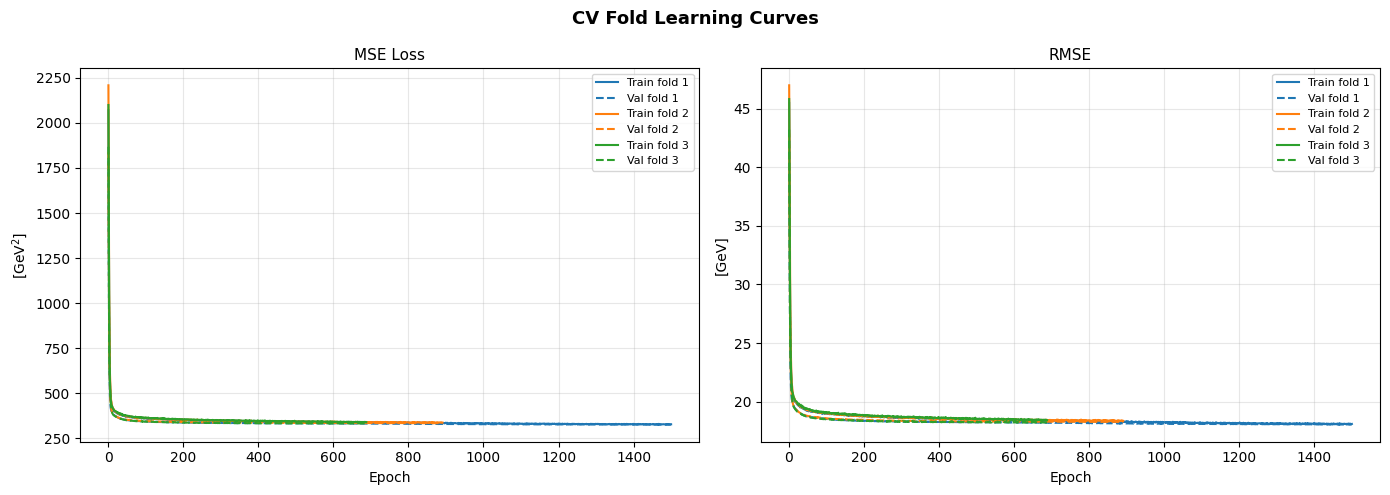

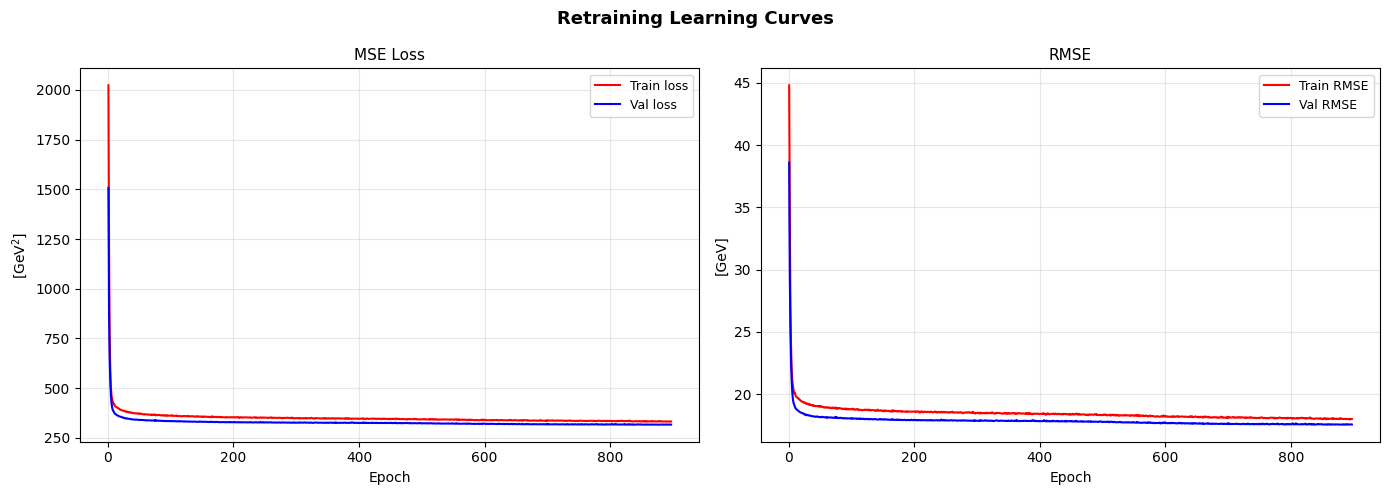

Retraining learning curves:
    Epochs run       : 897
    Final train loss : 332.4172
    Final val loss   : 316.7138
    Best val loss    : 316.0088  (epoch 837)


In [14]:

FOLD_LC_FILE = f"fold_histories.parquet"
LC_FILE    = f"learning_curves.parquet"

# Load fold learning curves (loss, val_loss, mse, val_mse)
df_folds = pd.read_parquet(FOLD_LC_FILE)

# Load learning curves (loss, val_loss, mse, val_mse)
df_lc = pd.read_parquet(LC_FILE)

# Fold learning curves
_plot_fold_learning_curves(df_folds)

# Learning curves
_plot_learning_curves(df_lc)

---

## DYJetsToLL

  Loaded 571,928 events from 'predictions_testing_DYJetsToLL.parquet'
  Columns found: ['MET_pt_pred', 'GenMET_pt', 'MET_pt']


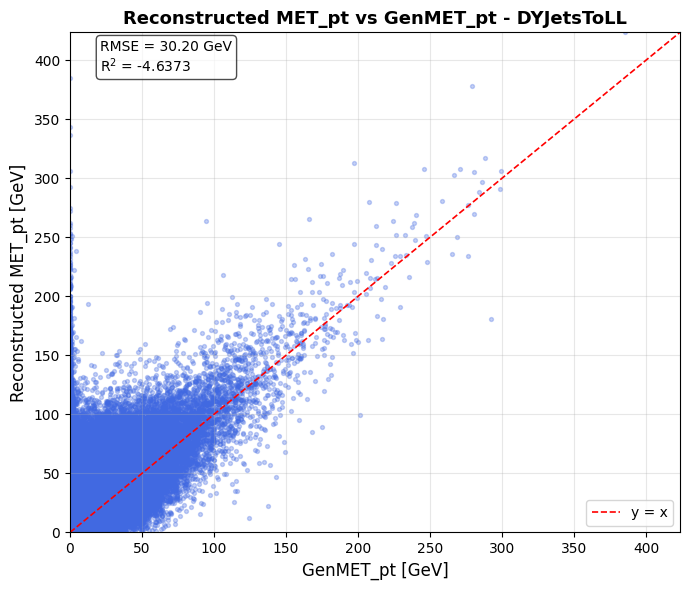

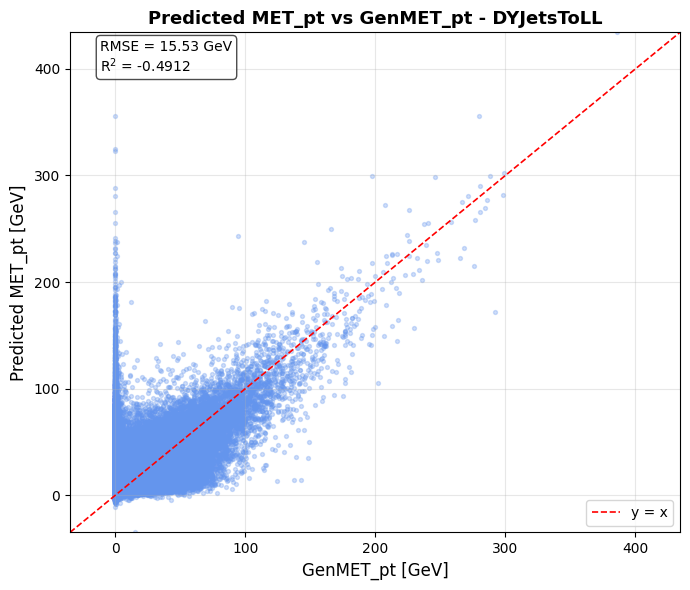

Reconstruction performance for DYJetsToLL:
    RMSE = 30.2043 GeV
    MAE  = 24.7115 GeV
    R²   = -4.6373
    Std(residuals) = 18.8062 GeV
ML model performance for DYJetsToLL:
    RMSE = 15.5348 GeV
    MAE  = 11.4277 GeV
    R²   = -0.4912
    Std(residuals) = 12.9557 GeV
Performance improvement for DYJetsToLL:
    DELTA_RMSE = 14.6695 GeV   +48.57%
    DELTA_MAE  = 13.2838 GeV    +53.76%
    DELTA_R²   = 4.1461    +89.41%
    DELTA_STD   = 5.8505    +31.11%


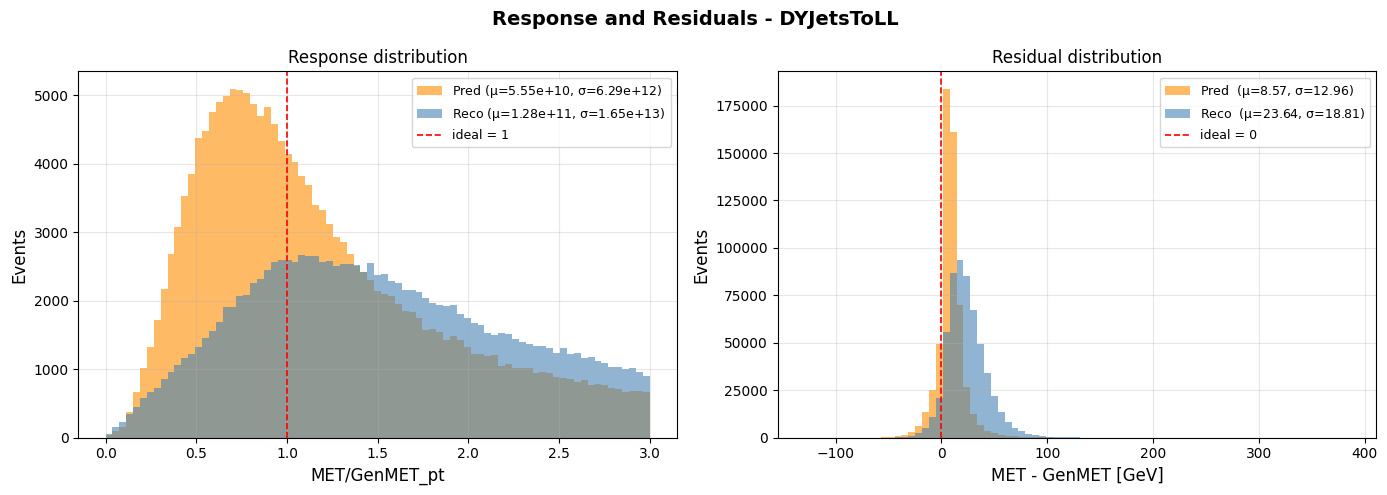

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 220 GeV.
  Last bin with >= 10 events: [210, 220] GeV, n=10


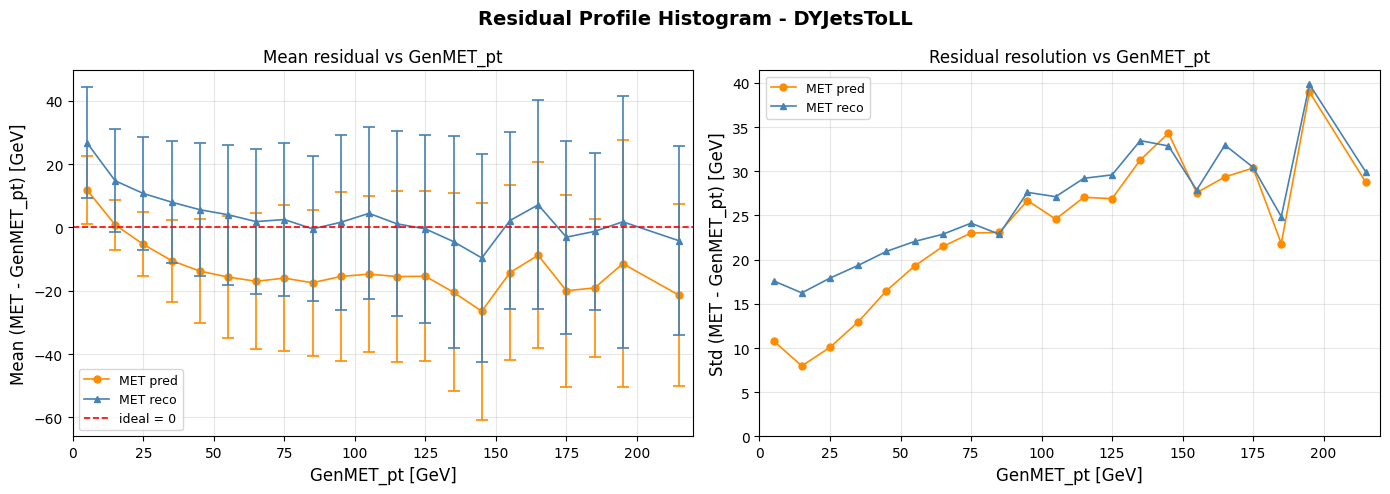

  Excluding GenMET_pt < 50.0 GeV: 563,912 events removed.
  Plotting up to 220 GeV.
  Last bin with >= 10 events: [210, 220] GeV, n=10


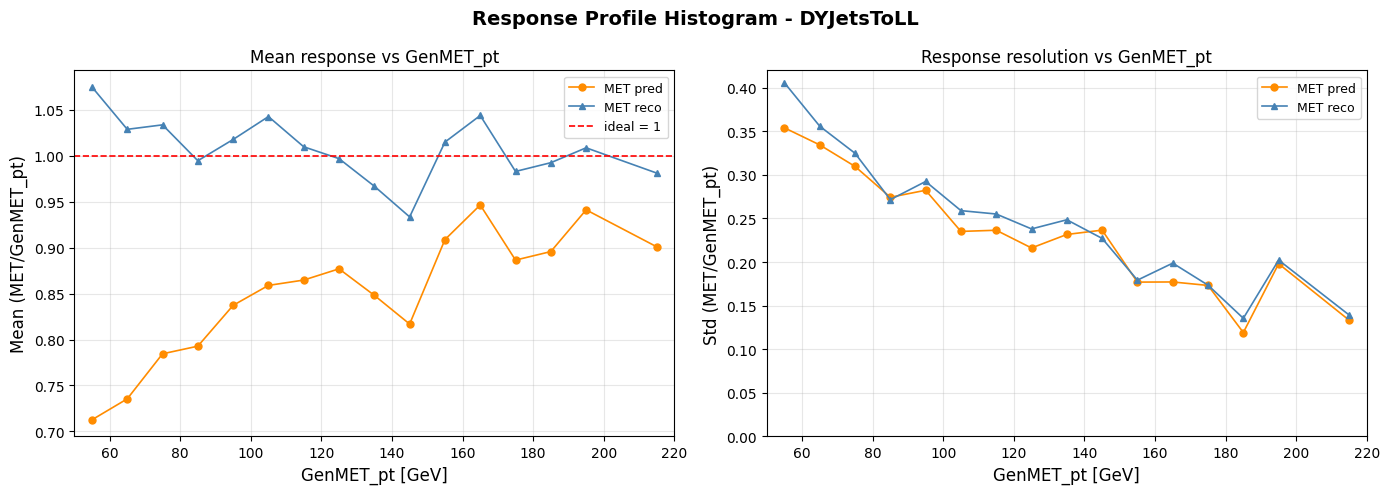

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 220 GeV.
  Last bin with >= 10 events: [210, 220] GeV, n=10


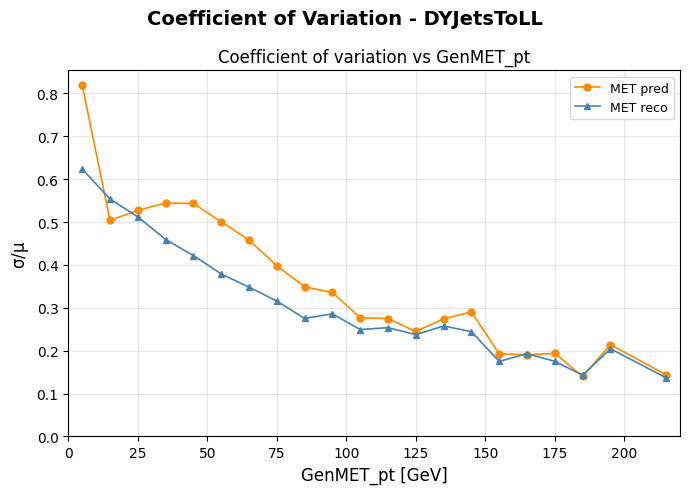

Coefficient of Variation comparison:
    Bins compared: 21 / 39
    Average improvement weighted by events count: -0.1561 (CoV_reco - CoV_pred)
    Fraction of bins where prediction improves CoV: 14.3%
    Best bin:  [10, 20] GeV -> Δ=+0.0499 (+9.0%)
    Worst bin: [0, 10] GeV -> Δ=-0.1961 (-31.5%)


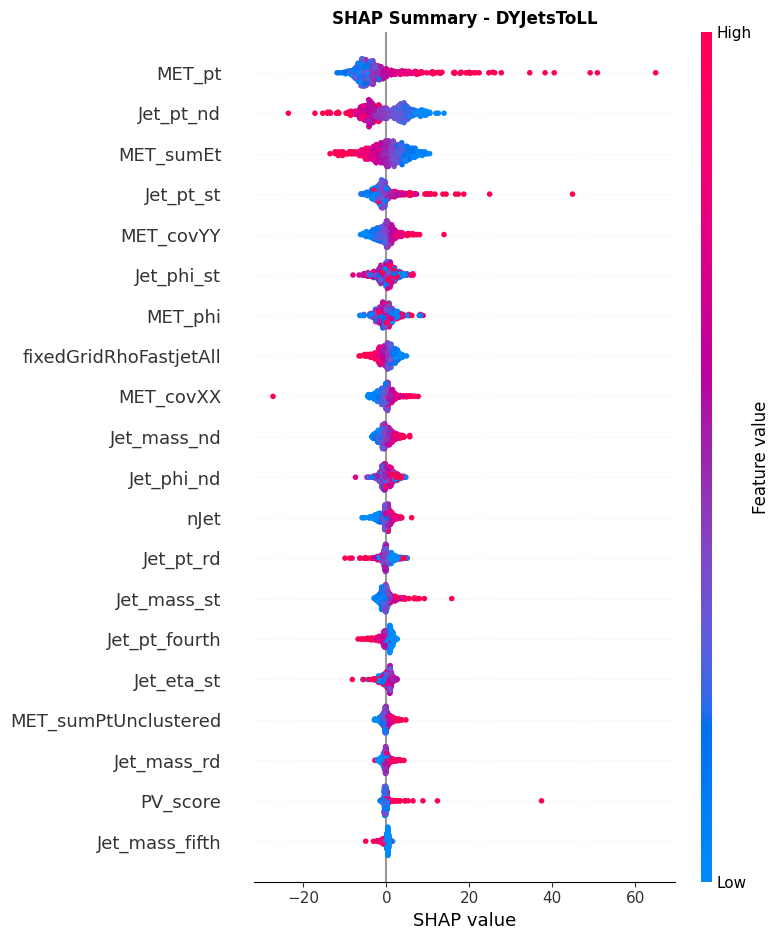

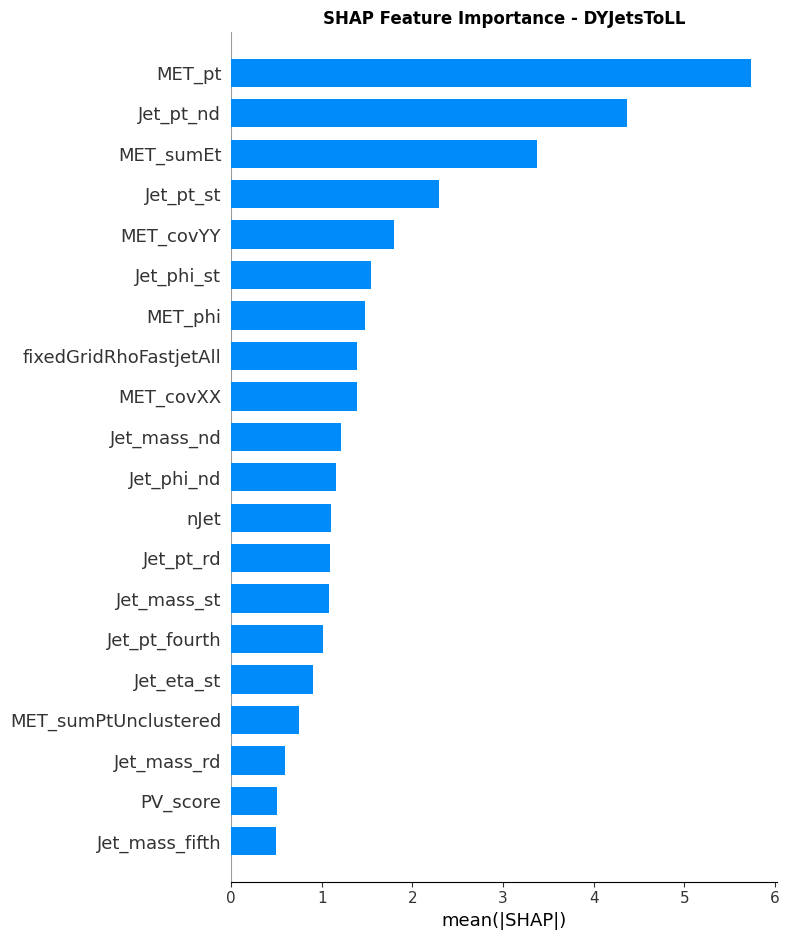


  Feature importance (mean |SHAP|) for DYJetsToLL:
    MET_pt                              5.7340
    Jet_pt_nd                           4.3636
    MET_sumEt                           3.3712
    Jet_pt_st                           2.2960
    MET_covYY                           1.7985
    Jet_phi_st                          1.5481
    MET_phi                             1.4830
    fixedGridRhoFastjetAll              1.3912
    MET_covXX                           1.3906
    Jet_mass_nd                         1.2102
    Jet_phi_nd                          1.1566
    nJet                                1.1060
    Jet_pt_rd                           1.0954
    Jet_mass_st                         1.0769
    Jet_pt_fourth                       1.0153
    Jet_eta_st                          0.9027
    MET_sumPtUnclustered                0.7555
    Jet_mass_rd                         0.5909
    PV_score                            0.5113
    Jet_mass_fifth                      0.4916
    fixe

In [15]:

EVENT      = "DYJetsToLL"
PRED_FILE = f"predictions_testing_{EVENT}.parquet"
MODEL_DIR = f"."

# Reconstructed/Predicted MET vs GenMET
y_pred, y_true, MET_pt = load_predictions(EVENT)

_scatterplot_reco_vs_gen(MET_pt, y_true, EVENT, color="royalblue")
_scatterplot_pred_vs_gen(y_pred, y_true, EVENT, color="cornflowerblue")

# Performance metrics
_compute_metrics(y_pred, y_true, MET_pt, label=EVENT)

# Response and residuals distributions
_response_and_residual_plots(y_pred, y_true, MET_pt, EVENT)

# Profile histogram residuals
_profile_histogram_residuals(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 0.0)

# Profile histogram response
_profile_histogram_response(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 50.0)

# Profile histogram CoV
_profile_coefficient_of_variation(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 0.0)

# SHAP
model, scaler, run_summary = load_model_and_scaler(MODEL_DIR)
_feature_importance_shap(model, EVENT)

---

## HToAATo2Mu2B

  Loaded 198,788 events from 'predictions_testing_HToAATo2Mu2B.parquet'
  Columns found: ['MET_pt_pred', 'GenMET_pt', 'MET_pt']


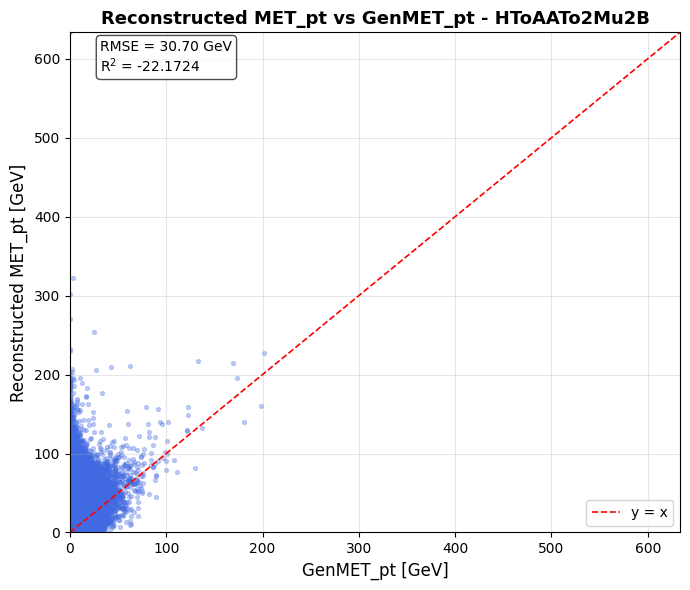

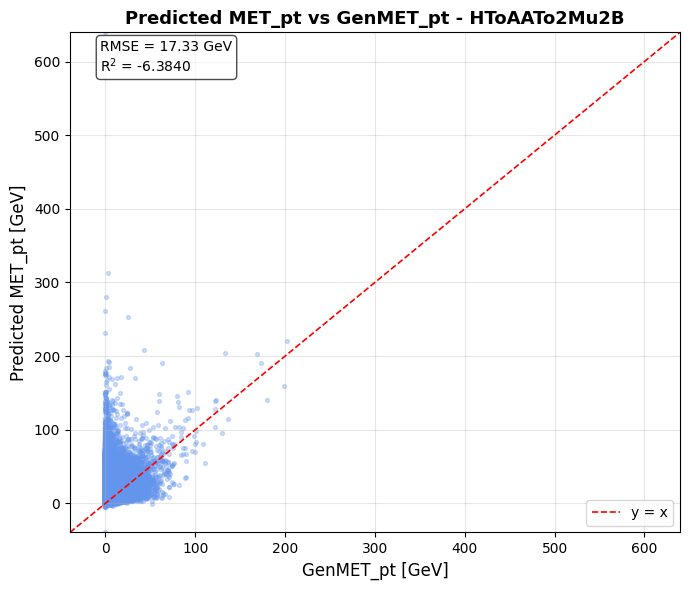

Reconstruction performance for HToAATo2Mu2B:
    RMSE = 30.6970 GeV
    MAE  = 25.0371 GeV
    R²   = -22.1724
    Std(residuals) = 18.3649 GeV
ML model performance for HToAATo2Mu2B:
    RMSE = 17.3283 GeV
    MAE  = 13.3054 GeV
    R²   = -6.3840
    Std(residuals) = 12.0646 GeV
Performance improvement for HToAATo2Mu2B:
    DELTA_RMSE = 13.3687 GeV   +43.55%
    DELTA_MAE  = 11.7316 GeV    +46.86%
    DELTA_R²   = 15.7885    +71.21%
    DELTA_STD   = 6.3003    +34.31%


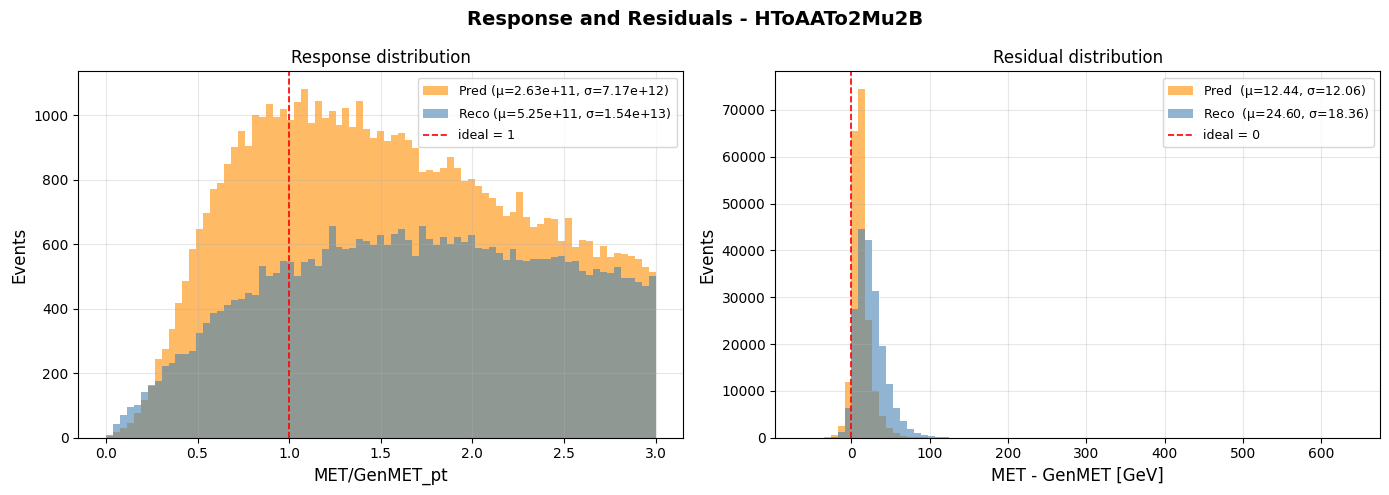

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 90 GeV.
  Last bin with >= 10 events: [80, 90] GeV, n=16


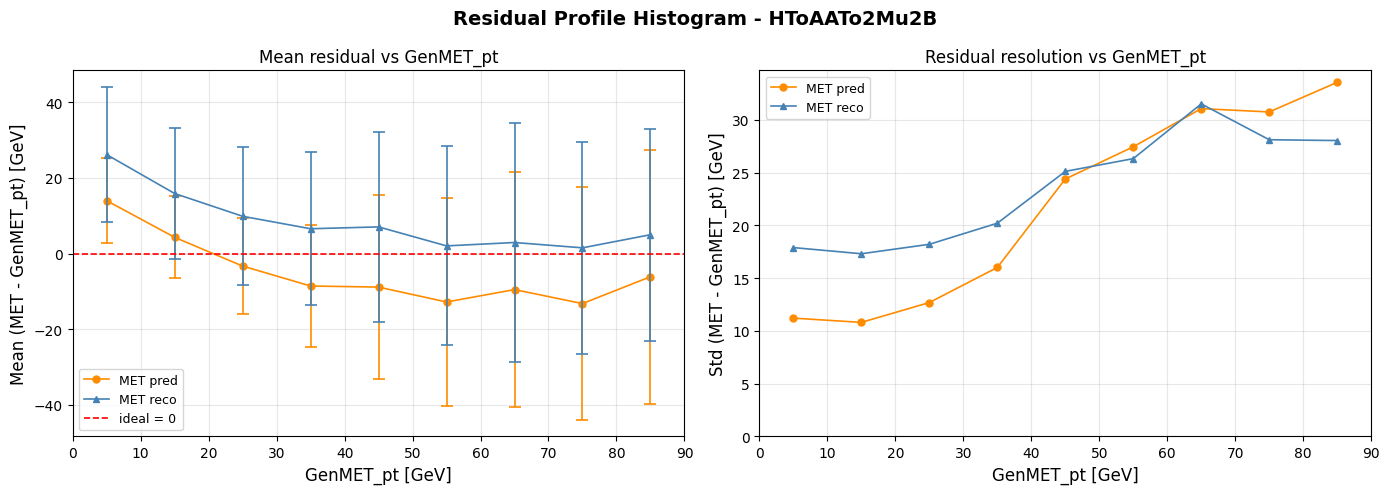

  Excluding GenMET_pt < 10.0 GeV: 172,523 events removed.
  Plotting up to 90 GeV.
  Last bin with >= 10 events: [80, 90] GeV, n=16


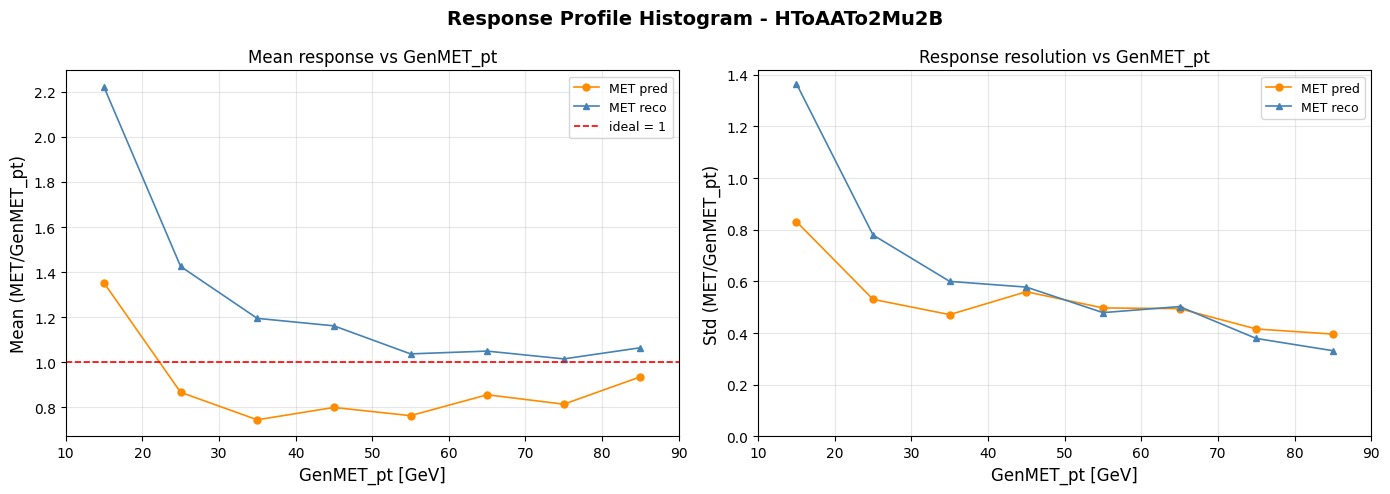

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 90 GeV.
  Last bin with >= 10 events: [80, 90] GeV, n=16


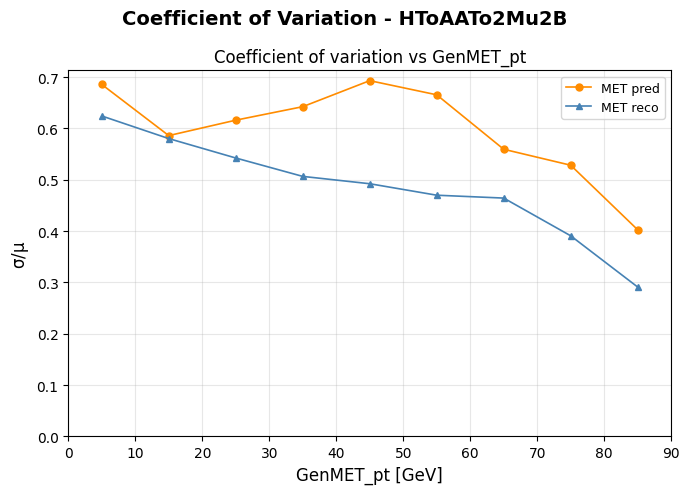

Coefficient of Variation comparison:
    Bins compared: 9 / 21
    Average improvement weighted by events count: -0.0566 (CoV_reco - CoV_pred)
    Fraction of bins where prediction improves CoV: 0.0%
    Best bin:  [10, 20] GeV -> Δ=-0.0058 (-1.0%)
    Worst bin: [40, 50] GeV -> Δ=-0.2008 (-40.8%)


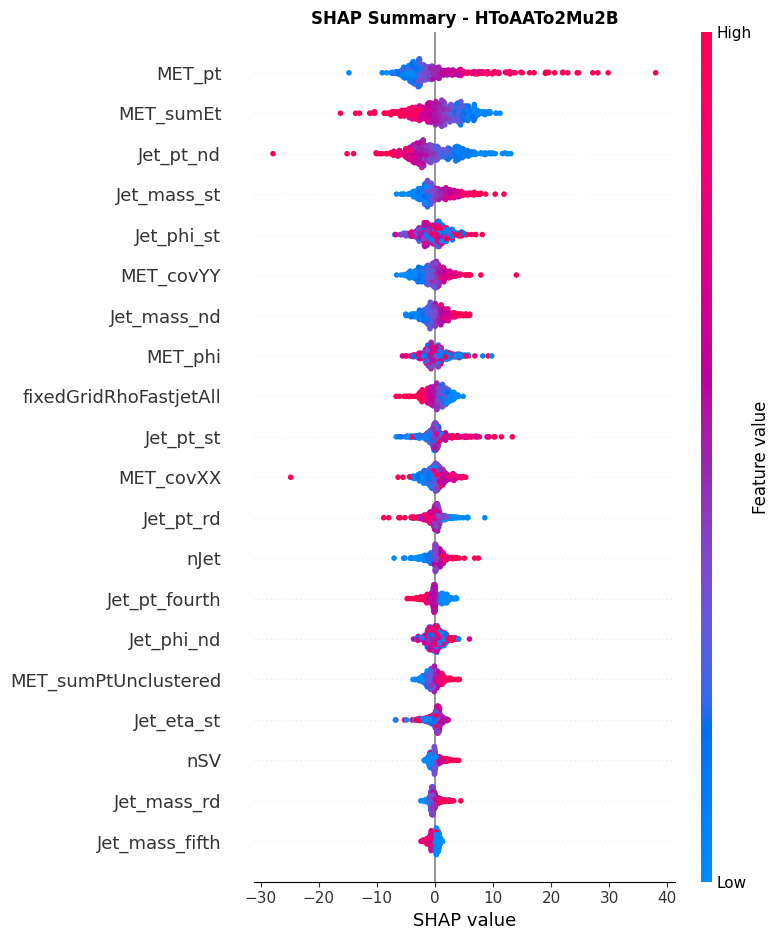

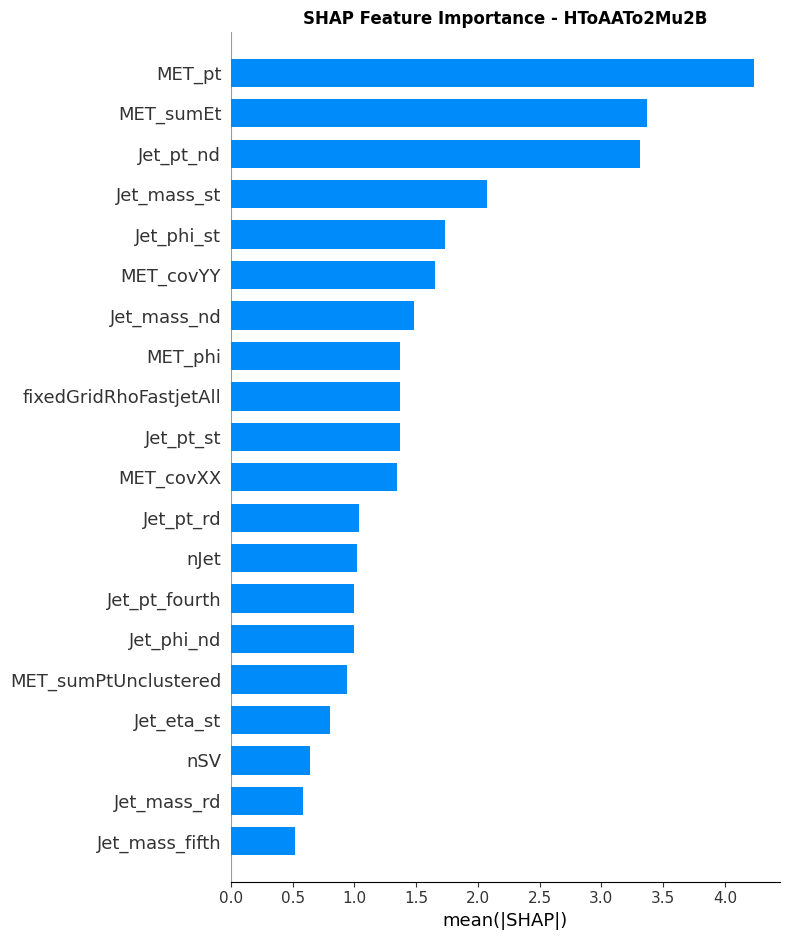


  Feature importance (mean |SHAP|) for HToAATo2Mu2B:
    MET_pt                              4.2344
    MET_sumEt                           3.3650
    Jet_pt_nd                           3.3143
    Jet_mass_st                         2.0703
    Jet_phi_st                          1.7356
    MET_covYY                           1.6556
    Jet_mass_nd                         1.4812
    MET_phi                             1.3712
    fixedGridRhoFastjetAll              1.3703
    Jet_pt_st                           1.3681
    MET_covXX                           1.3450
    Jet_pt_rd                           1.0348
    nJet                                1.0219
    Jet_pt_fourth                       0.9990
    Jet_phi_nd                          0.9947
    MET_sumPtUnclustered                0.9364
    Jet_eta_st                          0.7996
    nSV                                 0.6363
    Jet_mass_rd                         0.5806
    Jet_mass_fifth                      0.5220
    PV

In [16]:
EVENT      = "HToAATo2Mu2B"
PRED_FILE = f"predictions_testing_{EVENT}.parquet"
MODEL_DIR = f"."

# Reconstructed/Predicted MET vs GenMET
y_pred, y_true, MET_pt = load_predictions(EVENT)

_scatterplot_reco_vs_gen(MET_pt, y_true, EVENT, color="royalblue")
_scatterplot_pred_vs_gen(y_pred, y_true, EVENT, color="cornflowerblue")

# Performance metrics
_compute_metrics(y_pred, y_true, MET_pt, label=EVENT)

# Response and residuals distributions
_response_and_residual_plots(y_pred, y_true, MET_pt, EVENT)

# Profile histogram residuals
_profile_histogram_residuals(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 0.0)

# Profile histogram response
_profile_histogram_response(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 10.0)

# Profile histogram CoV
_profile_coefficient_of_variation(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 0.0)

# SHAP
model, scaler, run_summary = load_model_and_scaler(MODEL_DIR)
_feature_importance_shap(model, EVENT)

---

## ZZTo2L2Nu

  Loaded 158,930 events from 'predictions_testing_ZZTo2L2Nu.parquet'
  Columns found: ['MET_pt_pred', 'GenMET_pt', 'MET_pt']


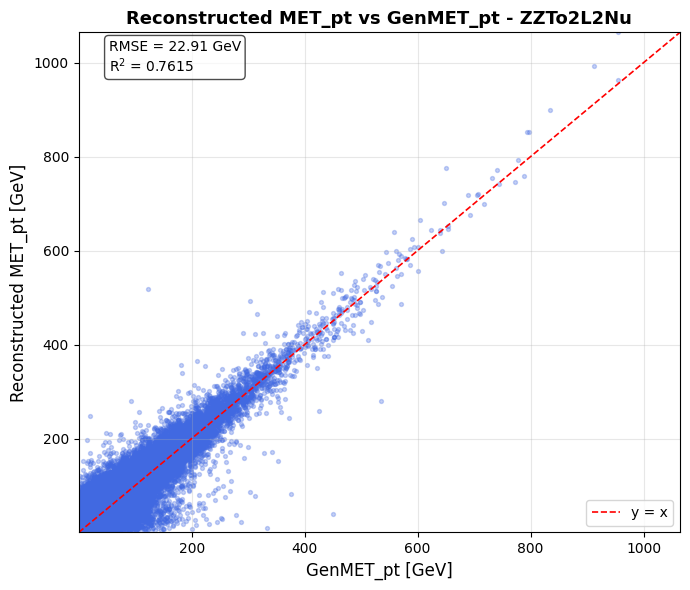

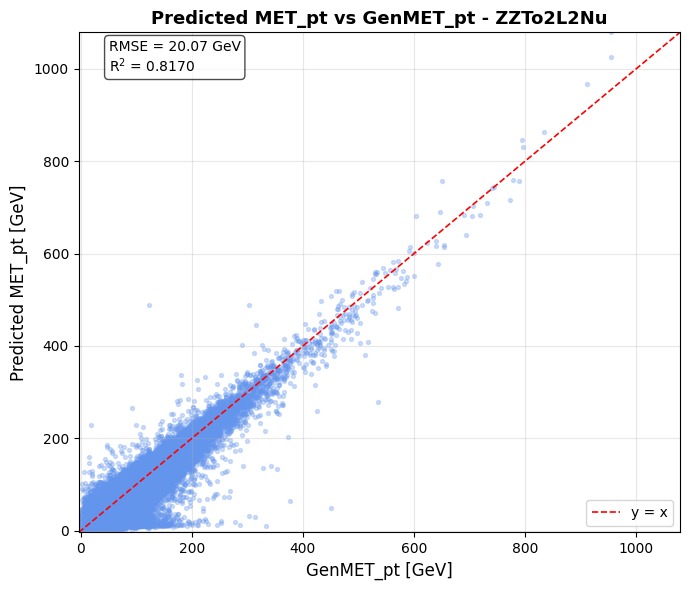

Reconstruction performance for ZZTo2L2Nu:
    RMSE = 22.9067 GeV
    MAE  = 17.2590 GeV
    R²   = 0.7615
    Std(residuals) = 21.5974 GeV
ML model performance for ZZTo2L2Nu:
    RMSE = 20.0680 GeV
    MAE  = 14.3038 GeV
    R²   = 0.8170
    Std(residuals) = 18.3666 GeV
Performance improvement for ZZTo2L2Nu:
    DELTA_RMSE = 2.8387 GeV   +12.39%
    DELTA_MAE  = 2.9552 GeV    +17.12%
    DELTA_R²   = 0.0554    +7.28%
    DELTA_STD   = 3.2308    +14.96%


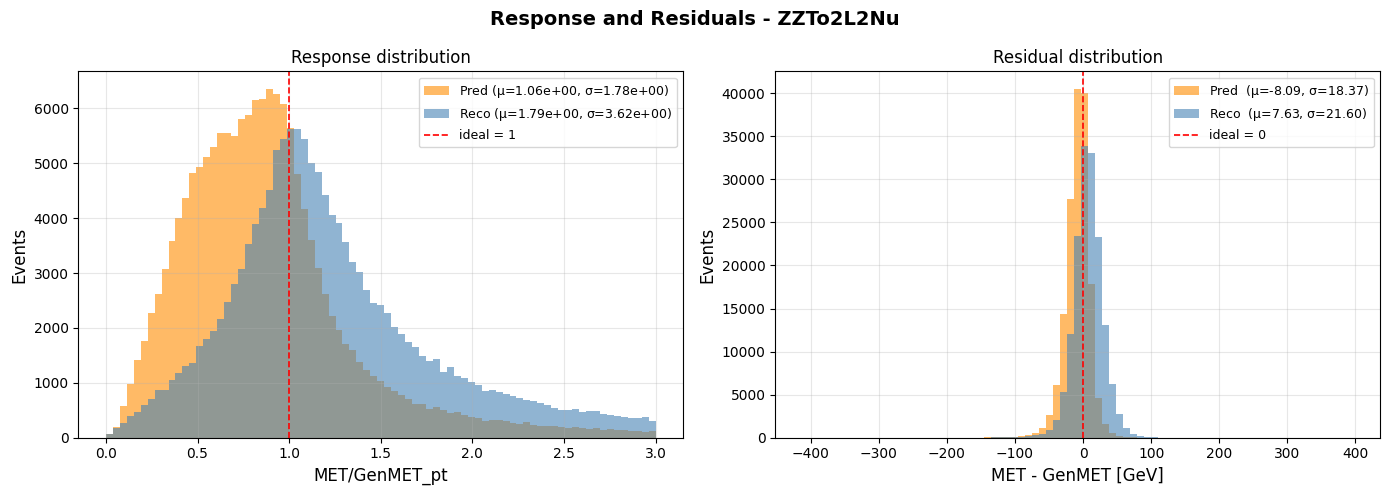

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 490 GeV.
  Last bin with >= 10 events: [480, 490] GeV, n=14


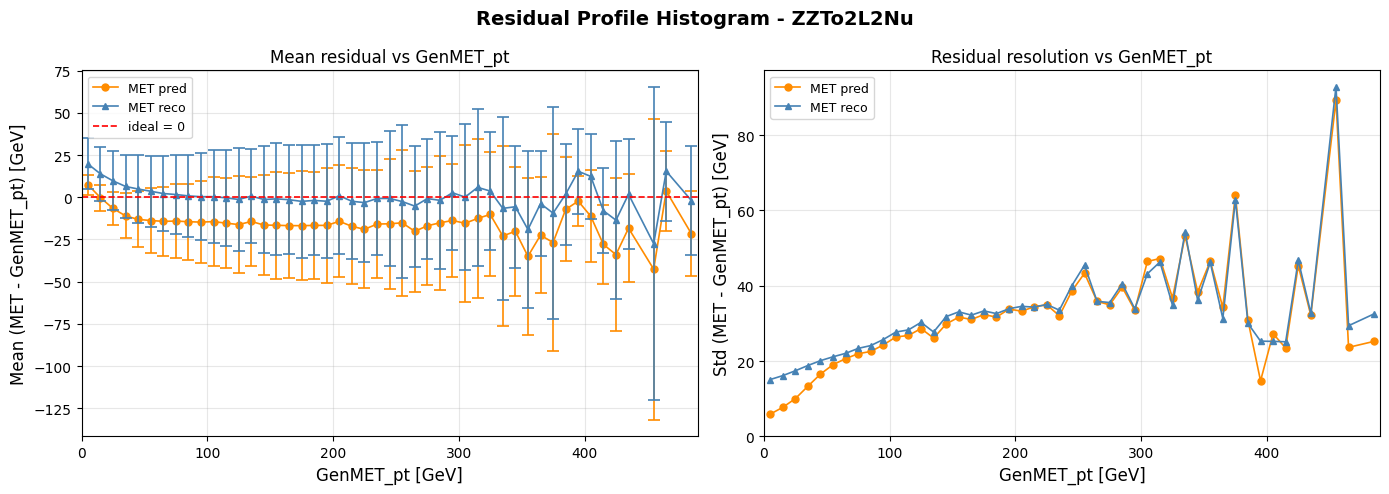

  Excluding GenMET_pt < 50.0 GeV: 103,687 events removed.
  Plotting up to 490 GeV.
  Last bin with >= 10 events: [480, 490] GeV, n=14


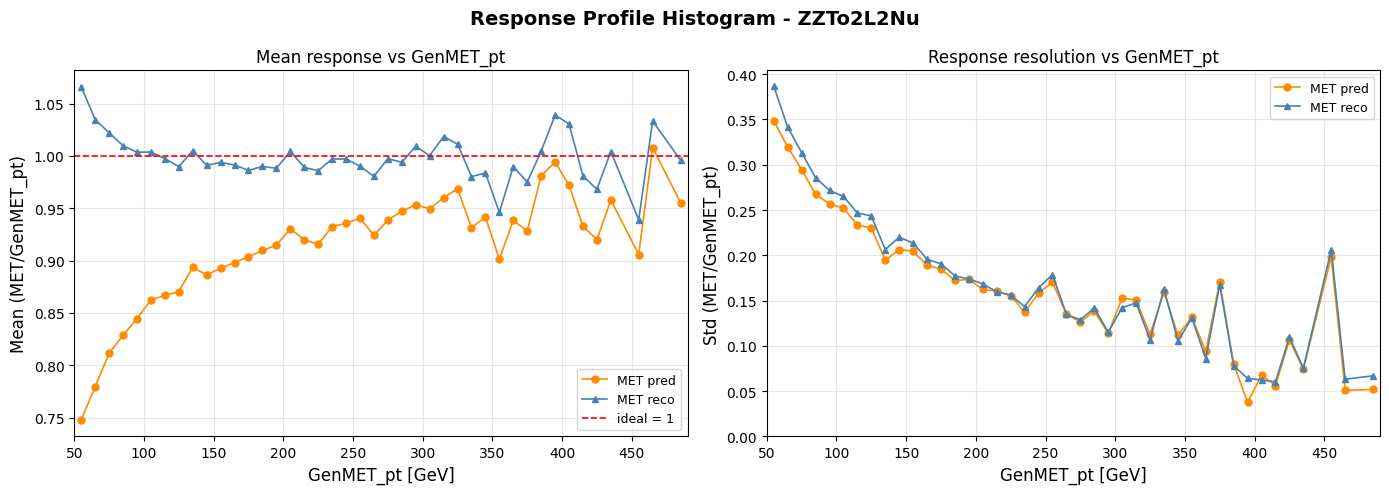

  Excluding GenMET_pt < 0.0 GeV: 0 events removed.
  Plotting up to 490 GeV.
  Last bin with >= 10 events: [480, 490] GeV, n=14


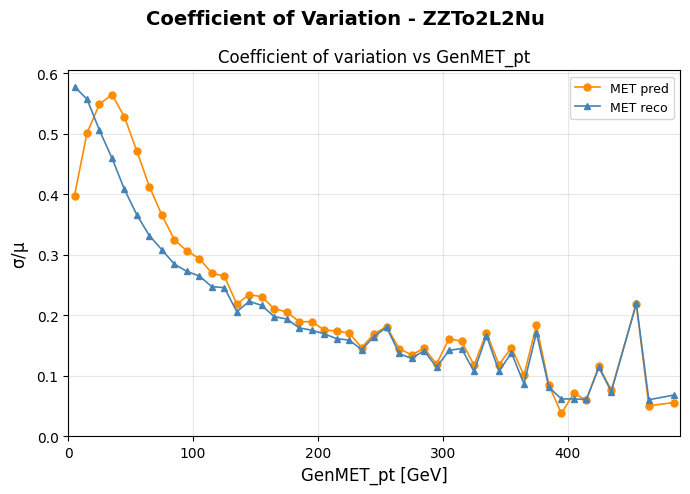

Coefficient of Variation comparison:
    Bins compared: 47 / 96
    Average improvement weighted by events count: -0.0242 (CoV_reco - CoV_pred)
    Fraction of bins where prediction improves CoV: 14.9%
    Best bin:  [0, 10] GeV -> Δ=+0.1798 (+31.1%)
    Worst bin: [40, 50] GeV -> Δ=-0.1199 (-29.4%)


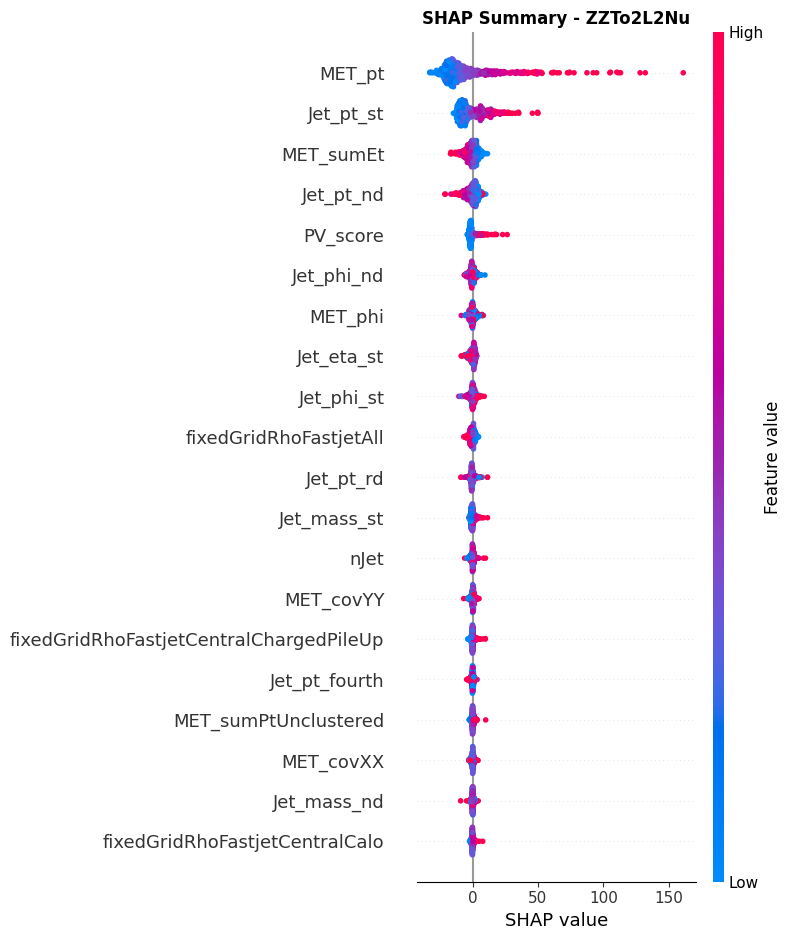

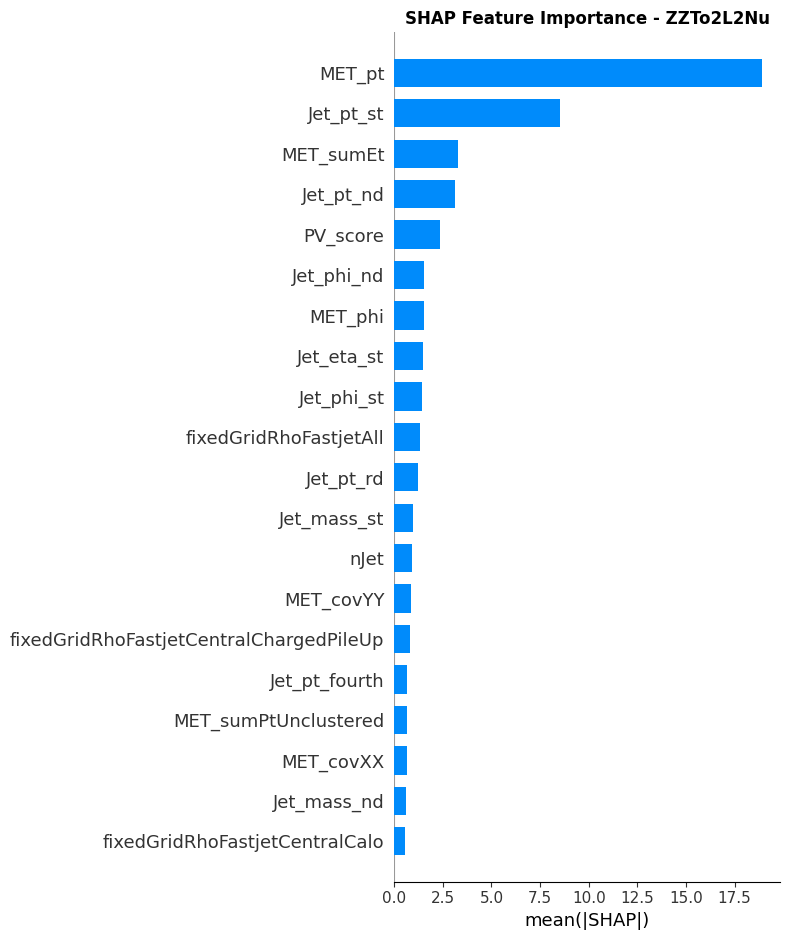


  Feature importance (mean |SHAP|) for ZZTo2L2Nu:
    MET_pt                              18.8896
    Jet_pt_st                           8.4996
    MET_sumEt                           3.2685
    Jet_pt_nd                           3.1467
    PV_score                            2.3395
    Jet_phi_nd                          1.5204
    MET_phi                             1.5178
    Jet_eta_st                          1.4866
    Jet_phi_st                          1.4193
    fixedGridRhoFastjetAll              1.3235
    Jet_pt_rd                           1.2059
    Jet_mass_st                         0.9762
    nJet                                0.8974
    MET_covYY                           0.8503
    fixedGridRhoFastjetCentralChargedPileUp 0.8184
    Jet_pt_fourth                       0.6719
    MET_sumPtUnclustered                0.6417
    MET_covXX                           0.6402
    Jet_mass_nd                         0.5995
    fixedGridRhoFastjetCentralCalo      0.5728
    

In [17]:
EVENT      = "ZZTo2L2Nu"
PRED_FILE = f"predictions_testing_{EVENT}.parquet"
MODEL_DIR = f"."

# Reconstructed/Predicted MET vs GenMET
y_pred, y_true, MET_pt = load_predictions(EVENT)

_scatterplot_reco_vs_gen(MET_pt, y_true, EVENT, color="royalblue")
_scatterplot_pred_vs_gen(y_pred, y_true, EVENT, color="cornflowerblue")

# Performance metrics
_compute_metrics(y_pred, y_true, MET_pt, label=EVENT)

# Response and residuals distributions
_response_and_residual_plots(y_pred, y_true, MET_pt, EVENT)

# Profile histogram residuals
_profile_histogram_residuals(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 0.0)

# Profile histogram response
_profile_histogram_response(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 50.0)

# Profile histogram CoV
_profile_coefficient_of_variation(y_pred, y_true, MET_pt, EVENT, min_counts = 10, min_Gen = 0.0)

# SHAP
model, scaler, run_summary = load_model_and_scaler(MODEL_DIR)
_feature_importance_shap(model, EVENT)